Using device: cuda
Epoch 10/2000 Accuracy: 89.84%
Epoch 20/2000 Accuracy: 91.41%
Epoch 30/2000 Accuracy: 91.80%
Epoch 40/2000 Accuracy: 90.23%
Epoch 50/2000 Accuracy: 90.23%
Epoch 60/2000 Accuracy: 91.41%
Epoch 70/2000 Accuracy: 91.41%
Epoch 80/2000 Accuracy: 90.23%
Epoch 90/2000 Accuracy: 91.02%
Epoch 100/2000 Accuracy: 91.80%
Epoch 110/2000 Accuracy: 91.41%
Epoch 120/2000 Accuracy: 91.02%
Epoch 130/2000 Accuracy: 91.80%
Epoch 140/2000 Accuracy: 92.19%
Epoch 150/2000 Accuracy: 91.41%
Epoch 160/2000 Accuracy: 91.80%
Epoch 170/2000 Accuracy: 92.19%
Epoch 180/2000 Accuracy: 91.41%
Epoch 190/2000 Accuracy: 92.19%
Epoch 200/2000 Accuracy: 92.19%
Epoch 210/2000 Accuracy: 91.80%
Epoch 220/2000 Accuracy: 92.19%
Epoch 230/2000 Accuracy: 91.41%
Epoch 240/2000 Accuracy: 91.41%
Epoch 250/2000 Accuracy: 91.41%
Epoch 260/2000 Accuracy: 91.80%
Epoch 270/2000 Accuracy: 92.19%
Epoch 280/2000 Accuracy: 91.80%
Epoch 290/2000 Accuracy: 92.19%
Epoch 300/2000 Accuracy: 92.19%
Epoch 310/2000 Accuracy: 92.58

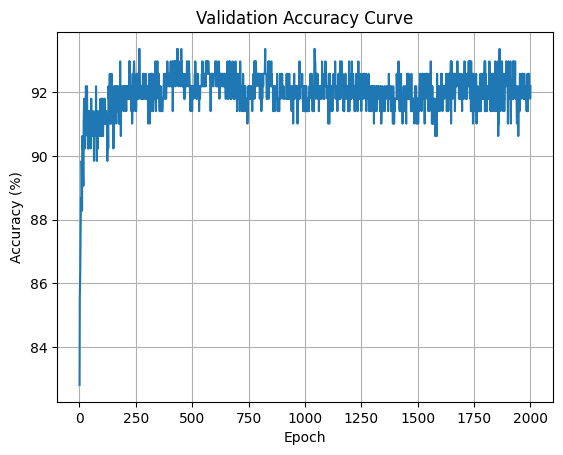

In [1]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = pd.read_csv("train.csv", encoding="latin1", sep=",", engine='python')


df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

for col in ['id', 'age_desc', 'relation']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

score_cols = [c for c in df.columns if "_score" in c]
df["total_score"] = df[score_cols].sum(axis=1)
df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
binary_features = [col for col in ["jaundice", "used_app_before", "family_mem_with_asd", "ethnicity", "gender"] if col in df.columns]
df["binary_sum"] = df[binary_features].sum(axis=1)
if "used_app_before" in df.columns and "total_score" in df.columns:
    df["used_score"] = df["used_app_before"] * df["total_score"]

target_col = 'class/asd' if 'class/asd' in df.columns else 'class_asd'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

class DeepASD(nn.Module):
    def __init__(self, input_dim):
        super(DeepASD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


model = DeepASD(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 2000
best_acc = 0
acc_list = []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_test)
        acc = (val_preds.round() == y_test).float().mean().item()
        acc_list.append(acc)
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} Accuracy: {acc * 100:.2f}%")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    final_preds = model(X_test)
    final_acc = (final_preds.round() == y_test).float().mean().item()
    map_score = average_precision_score(y_test.cpu().numpy(), final_preds.cpu().numpy())
    print(f"\n Mean Average Precision (mAP): {final_acc * 100:.2f}%")
   
plt.plot(range(1, epochs + 1), [a * 100 for a in acc_list])
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


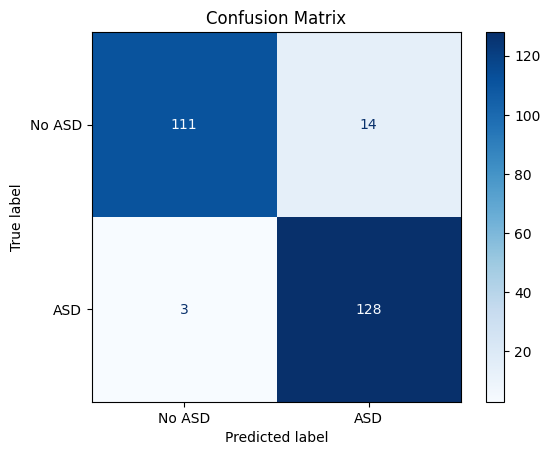

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = y_test.cpu().numpy()
y_pred = final_preds.round().cpu().numpy()


cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()
